In [14]:
from google.colab import files

# Esto abrirá el selector de archivos
uploaded = files.upload()

# Una vez cargado, puedes verificar el nombre del archivo
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving MATAMOROS.csv to MATAMOROS.csv
User uploaded file "MATAMOROS.csv" with length 5474 bytes


Sets definidos correctamente:
Train: 227 | Val: 65 | Test: 32

Entrenando modelos...


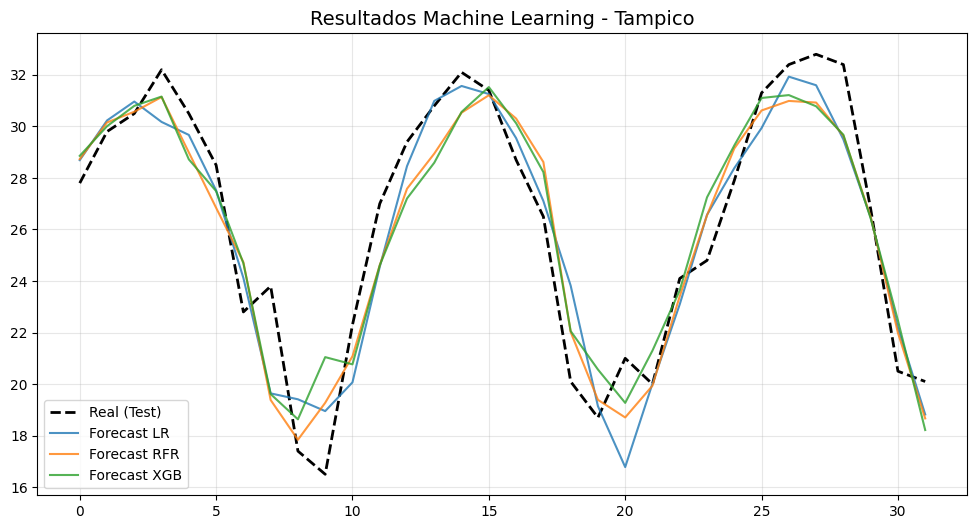


--- MÉTRICAS FINALES (TEST SET) ---
Model     RMSE    sMAPE     MASE        DA
   LR 1.786459 5.903596 0.566010 83.870968
  RFR 1.716006 5.860773 0.592831 80.645161
  XGB 1.900359 6.697653 0.661262 77.419355


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================================================
# 1. CARGA DE DATOS Y CORRECCIÓN DE COLUMNA
# =========================================================
#df_raw = pd.read_csv('TAMPICO.csv')
#df_raw = pd.read_csv('HOUSTON.csv')
#df_raw = pd.read_csv('MIAMI.csv')
df_raw = pd.read_csv('MATAMOROS.csv')

# SELECCIÓN SEGURA: Tomamos la segunda columna (índice 1) que es la temperatura
# Y nos aseguramos de que sea numérica
series = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce').values

# PARTICIÓN EXACTA (Protocolo 227/65/32)
train = series[0:227]
val   = series[227:292]
test  = series[292:324]

print(f"Sets definidos correctamente:")
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

# --- FUNCIONES DE MÉTRICAS Q1 ---
def calc_smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def calc_da(y_true, y_pred):
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)
    return 100 * np.mean(np.sign(y_true_diff) == np.sign(y_pred_diff))

def calc_mase(y_true, y_pred, y_train_history):
    d = np.abs(np.diff(y_train_history)).sum() / (len(y_train_history) - 1)
    return mean_absolute_error(y_true, y_pred) / d

def create_windows(series, window_size=12):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

# =========================================================
# 2. PREPARACIÓN PARA ML (VENTANA DE 12 MESES)
# =========================================================
window = 12
history = np.concatenate([train, val])

X_history, y_history = create_windows(history, window)
X_test, y_test = create_windows(np.concatenate([history[-window:], test]), window)

# =========================================================
# 3. ENTRENAMIENTO DE LOS 3 MODELOS
# =========================================================
print("\nEntrenando modelos...")

# Linear Regression
lr_model = LinearRegression().fit(X_history, y_history)
preds_lr = lr_model.predict(X_test)

# Random Forest
rfr_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42).fit(X_history, y_history)
preds_rfr = rfr_model.predict(X_test)

# XGBoost
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42).fit(X_history, y_history)
preds_xgb = xgb_model.predict(X_test)

# =========================================================
# 4. TABLA DE RESULTADOS Y GRÁFICA
# =========================================================
modelos = {"LR": preds_lr, "RFR": preds_rfr, "XGB": preds_xgb}
res_list = []

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Real (Test)', color='black', linewidth=2, linestyle='--')

for name, preds in modelos.items():
    # Calcular Métricas
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    smape = calc_smape(y_test, preds)
    mase = calc_mase(y_test, preds, history)
    da = calc_da(y_test, preds)

    res_list.append({"Model": name, "RMSE": rmse, "sMAPE": smape, "MASE": mase, "DA": da})

    # Graficar
    plt.plot(preds, label=f'Forecast {name}', alpha=0.8)

    # Exportar detallado para la tabla maestra posterior
    #pd.DataFrame({'Actual': y_test, 'Forecast': preds}).to_csv(f'TAMPICO_AVG_{name}_detailed.csv', index=False)
    #pd.DataFrame({'Actual': y_test, 'Forecast': preds}).to_csv(f'HOUSTON_AVG_{name}_detailed.csv', index=False)
    #pd.DataFrame({'Actual': y_test, 'Forecast': preds}).to_csv(f'MIAMI_AVG_{name}_detailed.csv', index=False)
    pd.DataFrame({'Actual': y_test, 'Forecast': preds}).to_csv(f'MATAMOROS_AVG_{name}_detailed.csv', index=False)

plt.title('Resultados Machine Learning - Tampico', fontsize=14)
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print("\n--- MÉTRICAS FINALES (TEST SET) ---")
print(pd.DataFrame(res_list).to_string(index=False))